# Saturating vs. non-saturating GAN loss — an experiment

From Goodfellow et al. (2014). The generator's objective in the literal minimax game is

$$\min_G \; \mathbb{E}_z\big[\log(1 - D(G(z)))\big] \qquad \text{(saturating)}$$

The paper's practical fix is to instead

$$\max_G \; \mathbb{E}_z\big[\log D(G(z))\big] \qquad \text{(non-saturating)}$$

Both share the same fixed point, but the claim is that the saturating form gives **almost no gradient
to $G$ early in training**, exactly when $D$ confidently rejects fakes ($D(G(z)) \approx 0$).

This notebook makes that observable in three escalating ways:

1. **Analytically** — plot the gradient magnitude each loss sends back, as a function of $D(G(z))$.
2. **At initialization** — measure the actual $\|\nabla_{\theta_G}\|$ through a real MLP for a confident $D$.
3. **Over full training** — train two GANs that differ *only* in the generator loss, and compare
   gradient norms and sample quality.

We use **MLP** generator and discriminator (as in the original paper) on a **2D mixture-of-Gaussians**
toy distribution. 2D keeps it fast and lets us literally plot $p_g$ against $p_{\text{data}}$. An MNIST
version (same idea, images) is in the appendix.

In [2]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = "cpu"
print("torch", torch.__version__, "| device:", device)

torch 2.4.1+cpu | device: cpu


## 1. The data: a 2D mixture of Gaussians

8 Gaussian blobs arranged in a ring. This is the classic minimal GAN benchmark — easy enough to train
in seconds, but multi-modal, so it can also reveal **mode collapse** (the paper's "Helvetica scenario").

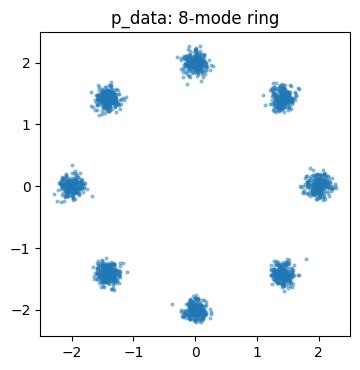

In [3]:
N_MODES = 8
RADIUS = 2.0
STD = 0.10

_angles = np.linspace(0, 2*np.pi, N_MODES, endpoint=False)
MODE_CENTERS = np.stack([RADIUS*np.cos(_angles), RADIUS*np.sin(_angles)], axis=1).astype(np.float32)

def sample_real(n):
    idx = np.random.randint(0, N_MODES, size=n)
    centers = MODE_CENTERS[idx]
    pts = centers + STD * np.random.randn(n, 2).astype(np.float32)
    return torch.from_numpy(pts)

real = sample_real(2000).numpy()
plt.figure(figsize=(4,4))
plt.scatter(real[:,0], real[:,1], s=4, alpha=0.4)
plt.title("p_data: 8-mode ring"); plt.gca().set_aspect("equal"); plt.show()

## 2. The models (MLPs)

- **Generator**: noise $z \in \mathbb{R}^2 \to \mathbb{R}^2$ sample.
- **Discriminator**: $\mathbb{R}^2 \to$ a single **logit** (we apply the sigmoid only where needed, so all
  losses can use numerically stable formulations).

In [4]:
Z_DIM = 2
H = 128

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, H), nn.ReLU(),
            nn.Linear(H, H), nn.ReLU(),
            nn.Linear(H, 2),                # output in data space
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, H), nn.LeakyReLU(0.2),
            nn.Linear(H, H), nn.LeakyReLU(0.2),
            nn.Linear(H, 1),                # returns a LOGIT (no sigmoid)
        )
    def forward(self, x): return self.net(x)

def noise(n): return torch.randn(n, Z_DIM)

## 3. Analytical view: how much gradient does each loss send back?

Let $p = D(G(z))$ be $D$'s probability that a fake is real, and $d$ the underlying logit so $p=\sigma(d)$.
The chain rule splits the generator gradient into $\frac{\partial L}{\partial d}\cdot\frac{\partial d}{\partial \theta_G}$.
The first factor is all that differs between the two losses:

| loss | $G$ minimizes | $\partial L / \partial d$ | at $p\to 0$ |
|---|---|---|---|
| saturating | $\log(1-p)$ | $-p$ | $\to 0$ (vanishes) |
| non-saturating | $-\log p$ | $-(1-p)$ | $\to -1$ (strong) |

So when $D$ is confident ($p\approx 0$, i.e. early training) the saturating loss multiplies *every*
downstream gradient by $\approx 0$. Plotting the magnitudes makes the gap obvious.

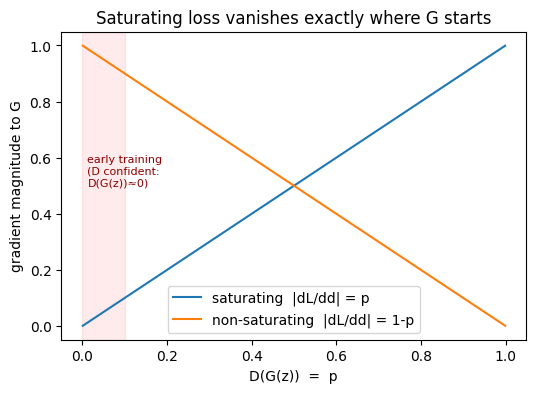

In [5]:
p = np.linspace(1e-3, 1-1e-3, 500)
grad_sat = p              # |dL/dd| for log(1-p)
grad_nonsat = (1 - p)     # |dL/dd| for -log(p)

plt.figure(figsize=(6,4))
plt.plot(p, grad_sat, label="saturating  |dL/dd| = p")
plt.plot(p, grad_nonsat, label="non-saturating  |dL/dd| = 1-p")
plt.axvspan(0, 0.1, color="red", alpha=0.08)
plt.text(0.012, 0.5, "early training\n(D confident:\nD(G(z))≈0)", fontsize=8, color="darkred")
plt.xlabel("D(G(z))  =  p"); plt.ylabel("gradient magnitude to G")
plt.title("Saturating loss vanishes exactly where G starts"); plt.legend(); plt.show()

## 4. Empirical view at initialization

The plot above is the *signal*; here we measure the *actual* parameter-gradient norm through the MLP.
We give $D$ a quick head start so it confidently rejects a fresh $G$'s samples (the realistic early-training
regime), then compute $\|\nabla_{\theta_G} L\|$ under each loss **on the same batch and the same $G$**.

In [6]:
def make_confident_D(G, steps=300):
    # Train a fresh D briefly so it confidently separates real data from this G's fakes.
    D = Discriminator()
    opt = torch.optim.Adam(D.parameters(), lr=1e-3)
    for _ in range(steps):
        x_real = sample_real(512)
        with torch.no_grad():
            x_fake = G(noise(512))
        d_real, d_fake = D(x_real), D(x_fake)
        loss = F.binary_cross_entropy_with_logits(d_real, torch.ones_like(d_real)) \
             + F.binary_cross_entropy_with_logits(d_fake, torch.zeros_like(d_fake))
        opt.zero_grad(); loss.backward(); opt.step()
    return D

def g_grad_norm(G, D, mode, batch=512):
    # L2 norm of the gradient the given loss pushes into G's parameters.
    G.zero_grad()
    d_fake = D(G(noise(batch)))                       # logits on fakes
    if mode == "saturating":                          # minimize log(1 - sigmoid(d)) = -softplus(d)
        loss = (-F.softplus(d_fake)).mean()
    elif mode == "nonsaturating":                     # minimize -log sigmoid(d) = softplus(-d)
        loss = F.softplus(-d_fake).mean()
    loss.backward()
    total = sum(pr.grad.pow(2).sum() for pr in G.parameters() if pr.grad is not None)
    return total.sqrt().item()

torch.manual_seed(1)
G0 = Generator()
D_conf = make_confident_D(G0)

with torch.no_grad():
    mean_p = torch.sigmoid(D_conf(G0(noise(2000)))).mean().item()
print(f"mean D(G(z)) on fakes  = {mean_p:.4f}   (close to 0 => D is confident)")

gn_sat    = g_grad_norm(G0, D_conf, "saturating")
gn_nonsat = g_grad_norm(G0, D_conf, "nonsaturating")
print(f"||grad_G||  saturating     = {gn_sat:.6f}")
print(f"||grad_G||  non-saturating = {gn_nonsat:.6f}")
print(f"ratio (nonsat / sat)       = {gn_nonsat/gn_sat:,.1f}x stronger")

mean D(G(z)) on fakes  = 0.0006   (close to 0 => D is confident)
||grad_G||  saturating     = 0.004671
||grad_G||  non-saturating = 5.303355
ratio (nonsat / sat)       = 1,135.3x stronger


## 5. Full training: change *only* the generator loss

Identical data, identical architectures, identical $D$ loss, identical initialization and seed. The single
difference is the generator's loss. We log $G$'s gradient norm at every step and snapshot samples along the way.

In [7]:
def train_gan(mode, steps=4000, batch=512, lr=1e-3, d_steps=1, snap_at=(0, 300, 1200, 4000)):
    torch.manual_seed(42)                 # same init for both runs
    G, D = Generator(), Discriminator()
    optG = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    optD = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

    g_grad_hist, snaps = [], {}
    def take_snap(step):
        with torch.no_grad():
            snaps[step] = G(noise(1500)).numpy()

    if 0 in snap_at: take_snap(0)
    for step in range(1, steps+1):
        # --- update D: maximize log D(x) + log(1 - D(G(z))) ---
        for _ in range(d_steps):
            x_real = sample_real(batch)
            with torch.no_grad(): x_fake = G(noise(batch))
            d_real, d_fake = D(x_real), D(x_fake)
            lossD = F.binary_cross_entropy_with_logits(d_real, torch.ones_like(d_real)) \
                  + F.binary_cross_entropy_with_logits(d_fake, torch.zeros_like(d_fake))
            optD.zero_grad(); lossD.backward(); optD.step()

        # --- update G ---
        d_fake = D(G(noise(batch)))
        if mode == "saturating":
            lossG = (-F.softplus(d_fake)).mean()      # min log(1 - D(G(z)))
        else:
            lossG = F.softplus(-d_fake).mean()        # min -log D(G(z))
        optG.zero_grad(); lossG.backward()
        gnorm = sum(pr.grad.pow(2).sum() for pr in G.parameters()).sqrt().item()
        g_grad_hist.append(gnorm)
        optG.step()

        if step in snap_at: take_snap(step)
    return G, np.array(g_grad_hist), snaps

G_sat,    grad_sat,    snaps_sat    = train_gan("saturating")
G_nonsat, grad_nonsat, snaps_nonsat = train_gan("nonsaturating")
print("done. final G grad norms -> saturating: %.4f | non-saturating: %.4f"
      % (grad_sat[-1], grad_nonsat[-1]))

done. final G grad norms -> saturating: 4.6254 | non-saturating: 0.6405


### 5a. Gradient norm over training

The saturating run starts near-flat (starved gradients) while the non-saturating run gets a strong signal
from step 1. A rolling mean is overlaid because per-step norms are noisy.

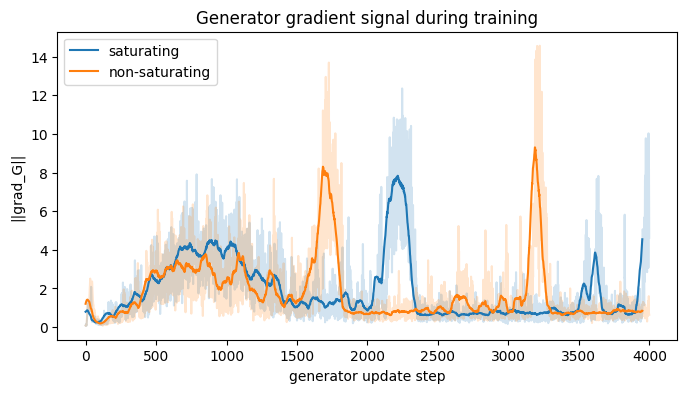

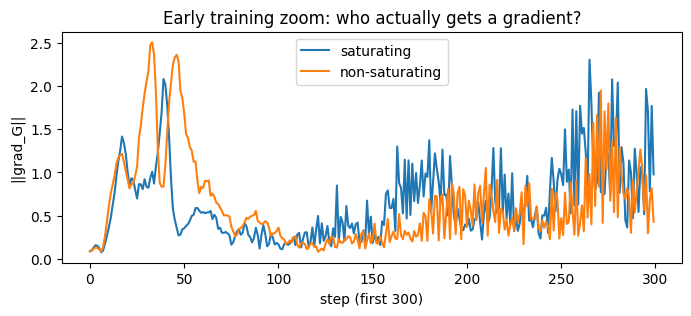

In [8]:
def smooth(x, k=50): 
    return np.convolve(x, np.ones(k)/k, mode="valid")

plt.figure(figsize=(8,4))
plt.plot(grad_sat, alpha=0.2, color="C0")
plt.plot(grad_nonsat, alpha=0.2, color="C1")
plt.plot(np.arange(len(smooth(grad_sat))), smooth(grad_sat), color="C0", label="saturating")
plt.plot(np.arange(len(smooth(grad_nonsat))), smooth(grad_nonsat), color="C1", label="non-saturating")
plt.xlabel("generator update step"); plt.ylabel("||grad_G||")
plt.title("Generator gradient signal during training"); plt.legend(); plt.show()

# zoom on the first 300 steps where the gap is starkest
plt.figure(figsize=(8,3))
plt.plot(grad_sat[:300], color="C0", label="saturating")
plt.plot(grad_nonsat[:300], color="C1", label="non-saturating")
plt.xlabel("step (first 300)"); plt.ylabel("||grad_G||")
plt.title("Early training zoom: who actually gets a gradient?"); plt.legend(); plt.show()

### 5b. What the generators actually produced

Real data in grey; generated samples in color. Watch how far each run has moved from the initial blob.

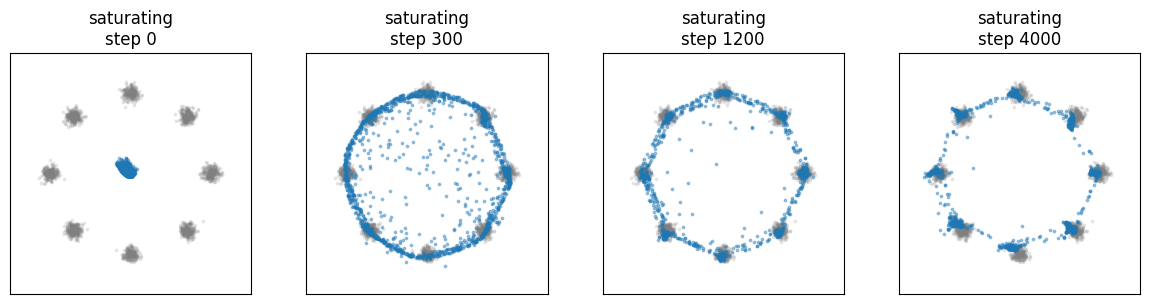

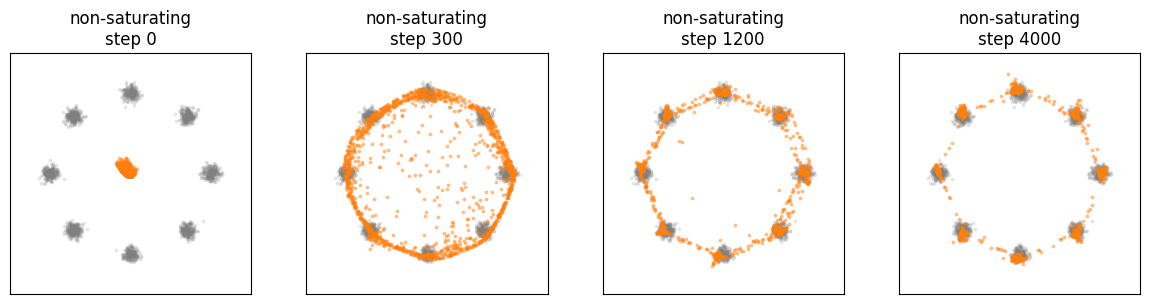

In [9]:
def plot_snaps(snaps, title, color):
    keys = sorted(snaps.keys())
    fig, axes = plt.subplots(1, len(keys), figsize=(3*len(keys), 3))
    for ax, k in zip(axes, keys):
        ax.scatter(real[:,0], real[:,1], s=3, alpha=0.15, color="grey")
        s = snaps[k]
        ax.scatter(s[:,0], s[:,1], s=3, alpha=0.4, color=color)
        ax.set_title(f"{title}\nstep {k}"); ax.set_aspect("equal")
        ax.set_xlim(-3,3); ax.set_ylim(-3,3); ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()

plot_snaps(snaps_sat,    "saturating",     "C0")
plot_snaps(snaps_nonsat, "non-saturating", "C1")

### 5c. Final side-by-side

How well does each $p_g$ cover $p_{\text{data}}$ at the end?

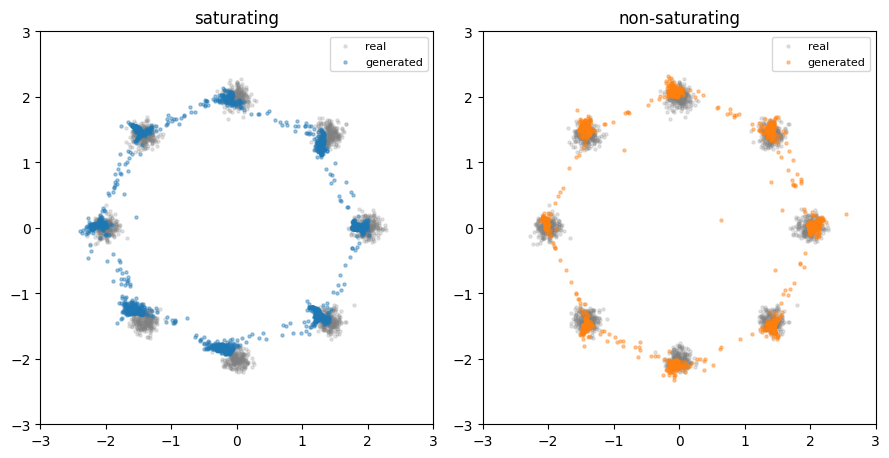

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, (G, name, c) in zip(axes, [(G_sat,"saturating","C0"), (G_nonsat,"non-saturating","C1")]):
    with torch.no_grad(): fake = G(noise(2000)).numpy()
    ax.scatter(real[:,0], real[:,1], s=5, alpha=0.2, color="grey", label="real")
    ax.scatter(fake[:,0], fake[:,1], s=5, alpha=0.4, color=c, label="generated")
    ax.set_title(name); ax.set_aspect("equal"); ax.legend(loc="upper right", fontsize=8)
    ax.set_xlim(-3,3); ax.set_ylim(-3,3)
plt.tight_layout(); plt.show()

## 6. What to take away

- **Section 3** shows the mechanism analytically: the saturating loss multiplies the generator's gradient
  by $D(G(z))$, which is $\approx 0$ precisely when $D$ wins early on. The non-saturating loss multiplies by
  $1 - D(G(z)) \approx 1$ instead.
- **Section 4** confirms it through a real MLP: with a confident $D$, the non-saturating loss delivers a
  parameter gradient many times larger than the saturating one — from an *identical* generator and batch.
- **Section 5** shows the consequence end-to-end: the non-saturating generator gets a usable learning signal
  immediately and moves toward the data, while the saturating one crawls early.

Both objectives share the same global optimum ($p_g = p_{\text{data}}$, $D=\tfrac12$). The difference is purely
about the *gradient* the generator receives on the way there — which is why essentially every modern GAN,
including the adversarial term in a SwinIR+GAN restoration setup, uses the non-saturating form.

> Try next: set `d_steps=3` in `train_gan` to make `D` stronger and starve the saturating generator harder;
> or shrink `STD` so the modes are tighter and mode collapse becomes easier to trigger.

## Appendix: the same experiment on MNIST images

This needs an MNIST download (and therefore network access + `torchvision`), so it won't run in a locked-down
sandbox — run it locally. The structure is identical: an MLP generator emitting a flattened 28×28 image, an MLP
discriminator returning a logit, and the same two generator-loss formulations. The saturating-vs-non-saturating
gradient story is the same; with images you additionally *see* it as sample sharpness early in training.

epoch 0 done
epoch 1 done
epoch 2 done
epoch 3 done
epoch 4 done
epoch 5 done
epoch 6 done
epoch 7 done
epoch 8 done
epoch 9 done
epoch 10 done
epoch 11 done
epoch 12 done
epoch 13 done
epoch 14 done
epoch 15 done
epoch 16 done
epoch 17 done
epoch 18 done
epoch 19 done


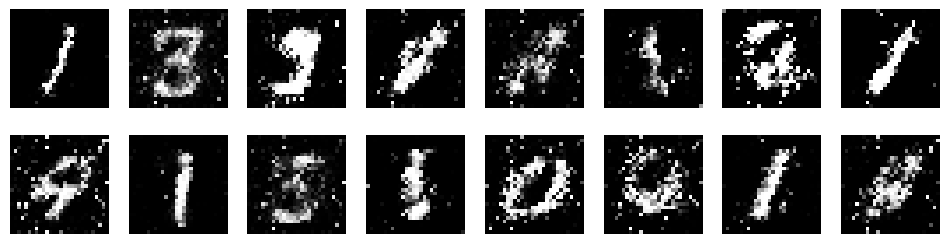

In [11]:
# --- LOCAL-ONLY: requires torchvision + internet to fetch MNIST ---
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader
#
tf = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])  # -> [-1, 1]
ds = torchvision.datasets.MNIST("./data", train=True, download=True, transform=tf)
dl = DataLoader(ds, batch_size=128, shuffle=True, drop_last=True)
#
IMG, ZL = 28*28, 64
Gm = nn.Sequential(nn.Linear(ZL,256), nn.ReLU(), nn.Linear(256,512), nn.ReLU(),
                   nn.Linear(512, IMG), nn.Tanh())                 # image in [-1,1]
Dm = nn.Sequential(nn.Linear(IMG,512), nn.LeakyReLU(0.2), nn.Linear(512,256),
                   nn.LeakyReLU(0.2), nn.Linear(256,1))            # logit
oG = torch.optim.Adam(Gm.parameters(), 2e-4, betas=(0.5,0.999))
oD = torch.optim.Adam(Dm.parameters(), 2e-4, betas=(0.5,0.999))
MODE = "nonsaturating"   # flip to "saturating" to compare
#
for epoch in range(20):
    for x,_ in dl:
        x = x.view(x.size(0), -1)
        z = torch.randn(x.size(0), ZL)
        dr, dfk = Dm(x), Dm(Gm(z).detach())
        lD = F.binary_cross_entropy_with_logits(dr, torch.ones_like(dr)) \
           + F.binary_cross_entropy_with_logits(dfk, torch.zeros_like(dfk))
        oD.zero_grad(); lD.backward(); oD.step()
        d = Dm(Gm(torch.randn(x.size(0), ZL)))
        lG = (-F.softplus(d)).mean() if MODE=="saturating" else F.softplus(-d).mean()
        oG.zero_grad(); lG.backward(); oG.step()
    print("epoch", epoch, "done")
#
import matplotlib.pyplot as plt
with torch.no_grad(): imgs = Gm(torch.randn(16, ZL)).view(-1,28,28).numpy()
fig, ax = plt.subplots(2,8, figsize=(12,3))
for a, im in zip(ax.ravel(), imgs): a.imshow((im+1)/2, cmap="gray"); a.axis("off")
plt.show()